# NY TaxiAID — Exploratory Data Analysis
### Yellow Taxi Trip Records · May 2022 · Parquet format

Predict the **fare** (`fare_amount`) and **duration** (minutes) of a NYC taxi ride using only
information available **at the start of the trip**.

**Notebook structure**

0. Install dependencies
1. Get data, establish parameters, create custom columns
2. Clean data
3. Explore the data
4. Find patterns & relationships
5. Visualize the insights
6. Generate business insights

## 0. Install dependencies

We install the libraries and set the display options. `pyarrow` is the engine pandas uses to read
Parquet files, so it is required even though we never import it directly.

In [5]:
# Uncomment the first time you run this notebook.
%pip install pandas pyarrow numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display options: show every column and round numbers to 2 decimals
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 3.0.6 | numpy 2.5.3


## 1. Get data, establish parameters, create custom columns

### 1.1 Parameters

Every configurable value lives in one place. When this notebook becomes `src/config.py`, all six
team members will import the exact same thresholds, which is what makes their results comparable.

In [7]:
# --- Paths -------------------------------------------------------------------
DATA_PATH  = "../data/raw/yellow_tripdata_2022-05.parquet"
ZONES_PATH = "../data/raw/taxi_zone_lookup.csv"   # optional, for zone names

# --- Expected period ---------------------------------------------------------
PERIOD_START = pd.Timestamp("2022-05-01")
PERIOD_END   = pd.Timestamp("2022-06-01")      # exclusive

# --- Time windows (defined by the team) --------------------------------------
MORNING_RUSH = (7, 9)      # 7:00 to 9:59
NIGHT_RUSH   = (17, 19)    # 17:00 to 19:59
WEEKEND_DAYS = (5, 6)      # Saturday and Sunday (Monday = 0)

# --- Physical validity thresholds --------------------------------------------
MIN_DURATION, MAX_DURATION = 1, 180      # minutes
MIN_DISTANCE, MAX_DISTANCE = 0.1, 100    # miles
MIN_FARE = 2.50                          # official NYC flag drop, 2022
MAX_FARE = 500
MIN_SPEED, MAX_SPEED = 1, 80             # mph

# --- Reference codes (TLC data dictionary) -----------------------------------
RATE_NEGOTIATED = 5        # agreed price, independent of distance and time
RATE_UNKNOWN = 99
UNKNOWN_ZONES = [264, 265]
AIRPORTS = {132: "JFK", 138: "LaGuardia", 1: "Newark"}

# --- Reproducibility ---------------------------------------------------------
RANDOM_STATE = 42
SAMPLE_SIZE = 200_000      # sample used for the heavier plots

### 1.2 Load the data

Parquet stores column types inside the file, so timestamps arrive already parsed as `datetime` and
`parse_dates` is unnecessary. It is also much faster and lighter than CSV, which is why the team
chose this format.

In [8]:
df = pd.read_parquet(DATA_PATH)

# The airport fee column is capitalized differently across years: normalize it
df = df.rename(columns={"Airport_fee": "airport_fee"})

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
df.head()

Rows: 3,588,295 | Columns: 19
Memory: 548.9 MB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.00,4.10,1.00,N,246,151,2,17.00,3.00,0.50,0.00,0.00,0.30,20.80,2.50,0.00
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.00,2.30,1.00,N,238,74,2,11.00,3.00,0.50,0.00,0.00,0.30,14.80,2.50,0.00
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.00,4.20,1.00,N,163,260,2,15.50,3.00,0.50,0.00,0.00,0.30,19.30,2.50,0.00
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.00,0.00,1.00,N,79,182,1,41.20,0.00,0.50,0.00,0.00,0.30,42.00,0.00,0.00
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.00,1.60,1.00,N,238,75,1,7.50,3.00,0.50,2.25,0.00,0.30,13.55,2.50,0.00


### 1.3 Classify the columns

We split the columns into three groups. This is the single most important step of the project:
`LEAKAGE` columns only exist **once the trip has ended**, so using them as features would produce a
model with excellent notebook metrics that is useless behind the API.

In [9]:
# What we want to predict
TARGETS = ["fare_amount", "duration_min"]

# Information available when the user requests an estimate
BASE_FEATURES = [
    "VendorID", "tpep_pickup_datetime", "passenger_count", "trip_distance",
    "RatecodeID", "PULocationID", "DOLocationID",
]

# Only known once the trip is over: these must NOT enter the model
LEAKAGE = [
    "tpep_dropoff_datetime", "payment_type", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "congestion_surcharge", "airport_fee", "store_and_fwd_flag",
]

unclassified = set(df.columns) - set(TARGETS + BASE_FEATURES + LEAKAGE)
print("Unclassified columns:", unclassified or "none")

Unclassified columns: none


### 1.4 Create custom columns

We build three families of columns:

- **The duration target:** it is not in the dataset, so we derive it from the two meter timestamps.
- **Diagnostic variables** (`avg_speed_mph`, `fare_per_mile`): these are not features, because they
  use the duration or the fare, which are exactly what we are trying to predict. They exist to
  **catch errors**: a trip at 200 mph or at 800 dollars per mile is impossible.
- **Time features** (`morning_rush`, `night_rush`, `weekend_rush` and others): these are valid
  features, since they are known before the trip starts. They are the core of the project's
  time-series angle.

In [10]:
# --- Targets -----------------------------------------------------------------
# Duration does not exist in the dataset: derive it from the two meter timestamps
df["duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# --- Diagnostic variables (NOT features) -------------------------------------
hours = df["duration_min"] / 60
df["avg_speed_mph"] = np.where(hours > 0, df["trip_distance"] / hours, np.nan)
df["fare_per_mile"] = np.where(df["trip_distance"] > 0,
                               df["fare_amount"] / df["trip_distance"], np.nan)

# --- Time features (valid features: known at pickup time) --------------------
pickup = df["tpep_pickup_datetime"]
df["pickup_date"] = pickup.dt.date
df["pickup_hour"] = pickup.dt.hour
df["pickup_dow"]  = pickup.dt.dayofweek          # 0 = Monday ... 6 = Sunday
df["pickup_day"]  = pickup.dt.day
df["pickup_week"] = pickup.dt.isocalendar().week.astype("int16")

# Congestion flags as defined by the team
df["morning_rush"] = df["pickup_hour"].between(*MORNING_RUSH)
df["night_rush"]   = df["pickup_hour"].between(*NIGHT_RUSH)
df["is_weekend"]   = df["pickup_dow"].isin(WEEKEND_DAYS)
# weekend_rush: weekend trip, following the team's agreed definition
df["weekend_rush"] = df["is_weekend"]
# Summary flag: does the trip fall in any weekday congestion window?
df["any_rush"] = (df["morning_rush"] | df["night_rush"]) & ~df["is_weekend"]

# Time of day as a category, handy for grouping and plotting
df["time_segment"] = pd.cut(
    df["pickup_hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["late night", "morning", "midday", "afternoon", "evening"],
)

# Combined segment: this is the variable used in the section 5 heat maps
df["rush_segment"] = np.select(
    [df["is_weekend"], df["morning_rush"], df["night_rush"]],
    ["weekend", "morning rush", "night rush"],
    default="off-peak",
)

# --- Location features -------------------------------------------------------
df["pu_airport"] = df["PULocationID"].map(AIRPORTS)     # NaN when not an airport
df["do_airport"] = df["DOLocationID"].map(AIRPORTS)
df["is_airport_trip"] = df["pu_airport"].notna() | df["do_airport"].notna()
df["same_zone"] = df["PULocationID"] == df["DOLocationID"]
df["unknown_zone"] = (df["PULocationID"].isin(UNKNOWN_ZONES)
                      | df["DOLocationID"].isin(UNKNOWN_ZONES))

new_cols = ["duration_min", "avg_speed_mph", "fare_per_mile", "pickup_hour", "pickup_dow",
            "morning_rush", "night_rush", "weekend_rush", "any_rush", "rush_segment",
            "time_segment", "is_airport_trip", "same_zone", "unknown_zone"]
print(f"Columns created: {len(new_cols)}")
df[["duration_min", "avg_speed_mph", "fare_per_mile", "rush_segment"]].head()

Columns created: 14


,duration_min,avg_speed_mph,fare_per_mile,rush_segment
0,18.70,13.16,4.15,weekend
1,13.82,9.99,4.78,weekend
2,15.37,16.40,3.69,weekend
3,39.73,0.00,NaN,weekend
4,9.38,10.23,4.69,weekend


**Other columns worth adding later**, noted here for the team:

- `is_holiday`: May 30, 2022 was Memorial Day, a Monday with atypical traffic.
- `centroid_distance`: geographic distance between zones, using the TLC shapefile. It would stand in
  for `trip_distance` in production, where only an estimate is available.
- Weather variables (optional project deliverable, via the OpenWeather API).
- `trips_last_hour_in_zone`: recent demand per zone. Careful: it must be computed from past data
  only, otherwise it introduces leakage.

## 2. Clean data

We work on a copy (`clean`) and keep a log of how many rows each rule removes. That traceability is
what lets the team justify the cleaning decisions to the mentor and the stakeholders.

In [11]:
clean = df.copy()
log = []   # record of what each step does

def log_step(step, before, after):
    """Store and print how many rows a cleaning step removed."""
    removed = before - after
    log.append({"step": step, "rows_before": before, "rows_after": after,
                "removed": removed, "pct": removed / before * 100})
    print(f"{step}: -{removed:,} rows ({removed / before:.2%})")

### 2.1 Handle missing values

First we measure **how many** values are missing and, more importantly, **whether they go missing
together**. If several columns always fail on the same rows, these are not random gaps but a block
of records produced in a different way, and that changes the decision entirely.

In [12]:
# Missing values per column
missing = clean.isna().sum().to_frame("missing")
missing["pct"] = missing["missing"] / len(clean) * 100
display(missing[missing["missing"] > 0].sort_values("pct", ascending=False))

# Do the gaps appear together? Count the combinations of empty columns
missing_cols = [c for c in missing[missing["missing"] > 0].index
                if c not in ["avg_speed_mph", "fare_per_mile"]]
if missing_cols:
    print("\nMost frequent missing-value patterns (True = value is missing):")
    display(clean[missing_cols].isna().value_counts().head(5))

,missing,pct
do_airport,3464330,96.55
pu_airport,3306996,92.16
passenger_count,129524,3.61
RatecodeID,129524,3.61
store_and_fwd_flag,129524,3.61
congestion_surcharge,129524,3.61
airport_fee,129524,3.61
fare_per_mile,46438,1.29
avg_speed_mph,3030,0.08



Most frequent missing-value patterns (True = value is missing):


passenger_count  RatecodeID  store_and_fwd_flag  congestion_surcharge  airport_fee  pu_airport  do_airport
False            False       False               False                 False        True        True          3083831
                                                                                    False       True           263897
True             True        True                True                  True         True        True           116029
False            False       False               False                 False        True        False           94279
                                                                                    False       False           16764
Name: count, dtype: int64

In [13]:
# Diagnosis: does the missing block behave differently from the rest?
block = clean["RatecodeID"].isna()

print("Medians per group (True = record arrived without metadata):")
display(clean.groupby(block)[["fare_amount", "trip_distance", "duration_min"]].median())

print("\nWhere the block comes from, by vendor:")
display(pd.crosstab(clean["VendorID"], block))

Medians per group (True = record arrived without metadata):


,fare_amount,trip_distance,duration_min
RatecodeID,,,
False,10.50,1.90,12.52
True,17.86,3.62,18.03



Where the block comes from, by vendor:


RatecodeID,False,True
VendorID,,
1,1040604,13526
2,2418167,109830
5,0,14
6,0,6154


**Decision:** keep these rows. They are real trips, longer and more expensive than average, and they
come from the two main vendors. Dropping them would bias the model against exactly the kind of trip
where a good estimate matters most. Instead we flag them.

In [14]:
before = len(clean)

# Flag that tells the model "this record arrived incomplete"
clean["missing_metadata"] = clean["RatecodeID"].isna()

# passenger_count: impute with 1, the most frequent value
clean["passenger_count"] = clean["passenger_count"].fillna(1)

# RatecodeID: missing values join code 99, which TLC already uses for "unknown"
clean["RatecodeID"] = clean["RatecodeID"].fillna(RATE_UNKNOWN)

# store_and_fwd_flag: its own category instead of a null
clean["store_and_fwd_flag"] = clean["store_and_fwd_flag"].fillna("U")

log_step("2.1 Missing values (imputed, no rows dropped)", before, len(clean))

2.1 Missing values (imputed, no rows dropped): -0 rows (0.00%)


### 2.2 Remove duplicates

Identical rows artificially inflate certain patterns and, worse, if they land on both sides of the
train/test split the model is evaluated on data it already saw during training, which inflates the
metrics.

In [15]:
before = len(clean)
n_duplicates = clean.duplicated().sum()
print(f"Fully duplicated rows: {n_duplicates:,}")

clean = clean.drop_duplicates()
log_step("2.2 Duplicates", before, len(clean))

Fully duplicated rows: 0
2.2 Duplicates: -0 rows (0.00%)


### 2.3 Fix incorrect formats

We cast every column to the type it deserves. The code columns (`VendorID`, `RatecodeID`) are
categories disguised as numbers: leaving them as floats would let a linear model conclude that code
4 is "twice" code 2, which means nothing.

In [16]:
# Codes: small integers (Int16 accepts nulls, unlike int16)
for col in ["VendorID", "RatecodeID", "payment_type", "PULocationID",
            "DOLocationID", "passenger_count"]:
    clean[col] = clean[col].astype("Int16")

# Text flags: category
clean["store_and_fwd_flag"] = clean["store_and_fwd_flag"].astype("category")
clean["rush_segment"] = clean["rush_segment"].astype("category")

# Amounts: float32 is precise enough and uses half the memory of float64
for col in ["fare_amount", "trip_distance", "duration_min", "avg_speed_mph", "total_amount"]:
    clean[col] = clean[col].astype("float32")

print(clean.dtypes)
print(f"\nMemory: {clean.memory_usage(deep=True).sum() / 1e6:,.1f} MB")

VendorID                          Int16
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   Int16
trip_distance                   float32
RatecodeID                        Int16
store_and_fwd_flag             category
PULocationID                      Int16
DOLocationID                      Int16
payment_type                      Int16
fare_amount                     float32
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float32
congestion_surcharge            float64
airport_fee                     float64
duration_min                    float32
avg_speed_mph                   float32
fare_per_mile                   float64
pickup_date                      object
pickup_hour                       int32
pickup_dow                        int32


### 2.4 Standardize inconsistent data

Here we apply the validity rules. The criterion is **physical**, not statistical: the question is not
"is this value unusual?" but "could this trip have happened?". A 90-minute ride to JFK at rush hour
is extreme but real, and the model needs to learn it; a 90-minute ride at 0.2 mph is a meter someone
forgot to close.

In [17]:
# Inventory of every rule BEFORE applying them, so the cleaning can be justified
out_of_period = ~clean["tpep_pickup_datetime"].between(
    PERIOD_START, PERIOD_END, inclusive="left")

rules = {
    "date outside May 2022":     out_of_period,
    "duration out of range":     ~clean["duration_min"].between(MIN_DURATION, MAX_DURATION),
    "distance out of range":     ~clean["trip_distance"].between(MIN_DISTANCE, MAX_DISTANCE),
    "fare out of range":         ~clean["fare_amount"].between(MIN_FARE, MAX_FARE),
    "impossible speed":          ~clean["avg_speed_mph"].between(MIN_SPEED, MAX_SPEED),
    "negotiated fare (rate 5)":  clean["RatecodeID"] == RATE_NEGOTIATED,
}

inventory = pd.DataFrame({
    "records": {k: int(v.fillna(True).sum()) for k, v in rules.items()}
})
inventory["pct"] = inventory["records"] / len(clean) * 100
display(inventory.sort_values("records", ascending=False))

,records,pct
impossible speed,59767,1.67
distance out of range,58603,1.63
duration out of range,54028,1.51
negotiated fare (rate 5),28382,0.79
fare out of range,22491,0.63
date outside May 2022,143,0.00


In [18]:
before = len(clean)

# Rule 1: the trip must belong to the period under analysis
clean = clean[~out_of_period.reindex(clean.index, fill_value=True)]

# Rule 2: physical validity of duration, distance and speed
clean = clean[
    clean["duration_min"].between(MIN_DURATION, MAX_DURATION)
    & clean["trip_distance"].between(MIN_DISTANCE, MAX_DISTANCE)
    & clean["avg_speed_mph"].between(MIN_SPEED, MAX_SPEED)
]

# Rule 3: the fare cannot be lower than the flag drop
clean = clean[clean["fare_amount"].between(MIN_FARE, MAX_FARE)]

log_step("2.4 Physical validity and period", before, len(clean))

2.4 Physical validity and period: -90,097 rows (2.51%)


**Negotiated fares are handled separately.** The price is agreed by a person before departure, so it
does not depend on distance or time and is impossible for the fare model to learn. Every extreme
outlier we found (0.10 miles for 450 dollars, 87 miles for 0.01) is of this kind. For the **duration**
model, on the other hand, those are perfectly valid trips, since the fare plays no part. That is why
each model gets its own dataset.

In [19]:
# Dataset for the DURATION model: negotiated fares included
clean_duration = clean.copy()

# Dataset for the FARE model: negotiated fares excluded
clean_fare = clean[clean["RatecodeID"] != RATE_NEGOTIATED].copy()

print(f"Original:         {len(df):,} rows")
print(f"Duration dataset: {len(clean_duration):,} rows ({len(clean_duration)/len(df):.2%})")
print(f"Fare dataset:     {len(clean_fare):,} rows ({len(clean_fare)/len(df):.2%})")

print("\nCleaning log:")
display(pd.DataFrame(log))

Original:         3,588,295 rows
Duration dataset: 3,498,198 rows (97.49%)
Fare dataset:     3,488,484 rows (97.22%)

Cleaning log:


,step,rows_before,rows_after,removed,pct
0,"2.1 Missing values (imputed, no rows dropped)",3588295,3588295,0,0.00
1,2.2 Duplicates,3588295,3588295,0,0.00
2,2.4 Physical validity and period,3588295,3498198,90097,2.51


## 3. Explore the data

### 3.1 Calculate summary statistics

The extreme percentiles (1 and 99) show whether any implausible value survived the cleaning.
Comparing the mean against the median reveals how skewed each variable is: when the mean is clearly
higher, the right tail carries a lot of weight.

In [20]:
summary_cols = ["trip_distance", "duration_min", "fare_amount",
                "avg_speed_mph", "fare_per_mile", "passenger_count"]

summary = clean_fare[summary_cols].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary["skew"] = clean_fare[summary_cols].skew()   # skewness: 0 = symmetric
display(summary)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,skew
trip_distance,"3,488,484.00",3.67,4.50,0.10,0.37,1.20,2.00,3.77,15.95,20.19,98.30,2.65
duration_min,"3,488,484.00",16.57,13.35,1.00,2.25,7.87,12.83,20.65,43.23,68.73,179.82,2.31
fare_amount,"3,488,484.00",14.90,12.64,2.50,4.00,7.50,10.50,16.95,52.00,54.00,430.00,2.52
avg_speed_mph,"3,488,484.00",11.99,6.48,1.00,3.51,7.77,10.31,14.19,25.30,35.75,79.72,1.86
fare_per_mile,"3,488,484.00",5.57,4.05,0.17,2.64,4.05,5.12,6.43,9.32,13.33,833.33,55.92
passenger_count,"3,488,484.00",1.38,0.94,0.00,0.00,1.00,1.00,1.00,3.00,6.00,6.00,2.82


### 3.2 Check data distribution

Both targets have a long right tail: many short, cheap trips and a few very long ones. This tells us
two things: a log transform of the target is worth testing, and MAE and RMSE will tell different
stories, because RMSE punishes large errors far more.

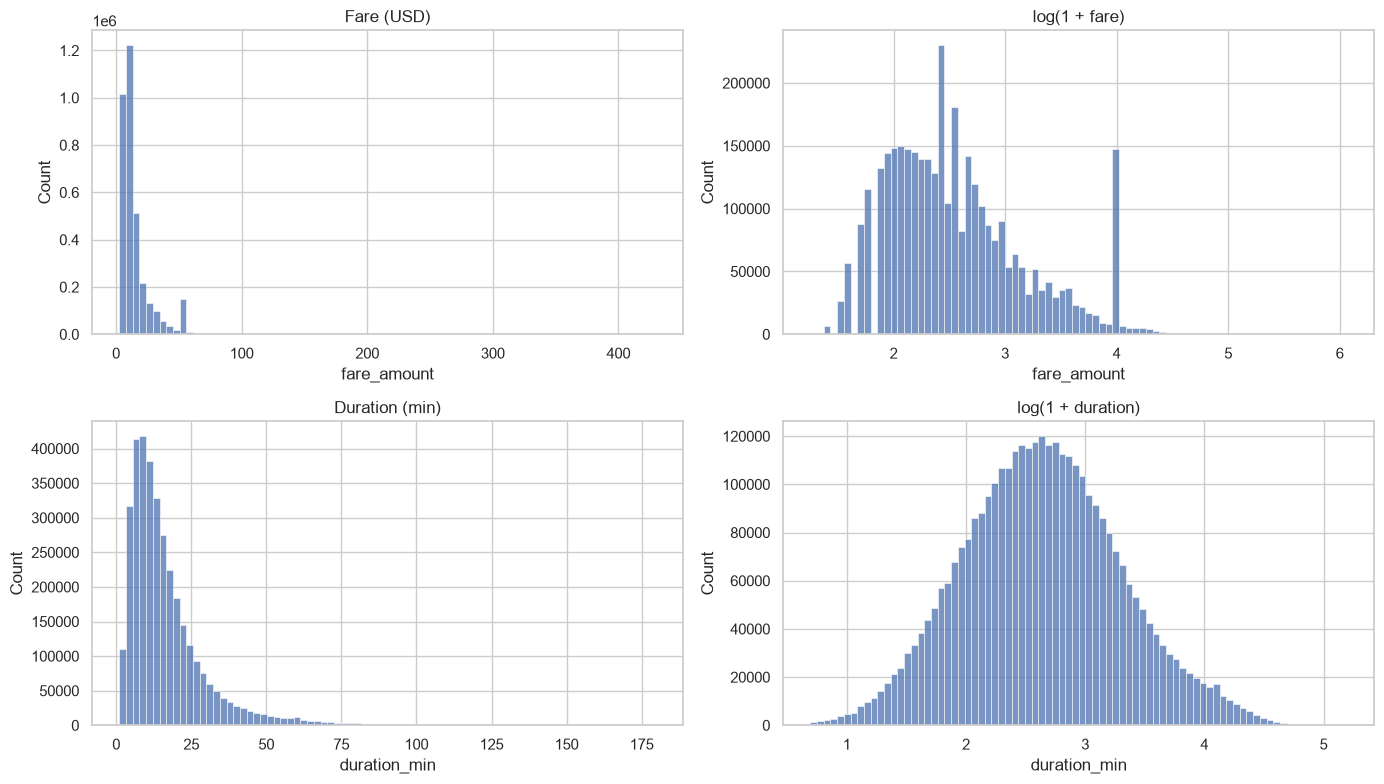

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original scale: the long tail is visible
sns.histplot(clean_fare["fare_amount"], bins=80, ax=axes[0, 0]).set_title("Fare (USD)")
sns.histplot(clean_fare["duration_min"], bins=80, ax=axes[1, 0]).set_title("Duration (min)")

# Log scale: the distribution becomes nearly normal
sns.histplot(np.log1p(clean_fare["fare_amount"]), bins=80, ax=axes[0, 1]).set_title("log(1 + fare)")
sns.histplot(np.log1p(clean_fare["duration_min"]), bins=80, ax=axes[1, 1]).set_title("log(1 + duration)")

plt.tight_layout()
plt.show()

### 3.3 Identify key variables

We measure how much each candidate variable separates the targets. For numeric variables we use
Spearman correlation (it does not require a linear relationship) and for categorical ones we compare
medians across groups: if a variable does not move the median, it carries little signal.

In [22]:
sample = clean_fare.sample(n=min(SAMPLE_SIZE, len(clean_fare)), random_state=RANDOM_STATE)

# Numeric variables: correlation with each target
num_feats = ["trip_distance", "passenger_count", "pickup_hour", "pickup_dow"]
target_corr = sample[num_feats + TARGETS].astype(float).corr(method="spearman")[TARGETS]
print("Spearman correlation with the targets:")
display(target_corr.drop(TARGETS))

# Categorical variables: do they move the median of the target?
for col in ["rush_segment", "is_airport_trip", "missing_metadata", "RatecodeID"]:
    grouped = (clean_fare.groupby(col, observed=True)
               .agg(trips=("fare_amount", "size"),
                    median_fare=("fare_amount", "median"),
                    median_duration=("duration_min", "median"),
                    median_speed=("avg_speed_mph", "median")))
    print(f"\n=== {col} ===")
    display(grouped)

Spearman correlation with the targets:


,fare_amount,duration_min
trip_distance,0.94,0.86
passenger_count,0.02,0.03
pickup_hour,-0.01,-0.00
pickup_dow,0.01,-0.01



=== rush_segment ===


,trips,median_fare,median_duration,median_speed
rush_segment,,,,
morning rush,318425,10.00,12.57,9.90
night rush,524947,10.00,12.87,9.32
off-peak,1703463,10.50,13.18,10.08
weekend,941649,10.50,12.28,11.49



=== is_airport_trip ===


,trips,median_fare,median_duration,median_speed
is_airport_trip,,,,
False,3120398,9.50,11.75,9.75
True,368086,44.00,36.83,21.82



=== missing_metadata ===


,trips,median_fare,median_duration,median_speed
missing_metadata,,,,
False,3364233,10.50,12.63,10.25
True,124251,17.61,18.48,12.12



=== RatecodeID ===


,trips,median_fare,median_duration,median_speed
RatecodeID,,,,
1,3202025,10.00,12.12,10.00
2,139548,52.00,49.42,22.00
3,10488,69.00,40.65,25.85
4,4449,65.00,34.37,33.47
6,4,5.50,6.62,13.64
99,131970,18.10,19.00,12.04


## 4. Find patterns & relationships

### 4.1 Analyze trends over time

The project has a time-series angle, so these patterns are the foundation of the time features. The
daily series also tells us whether the month is stable or whether there are atypical days worth
reviewing before the train/test split.

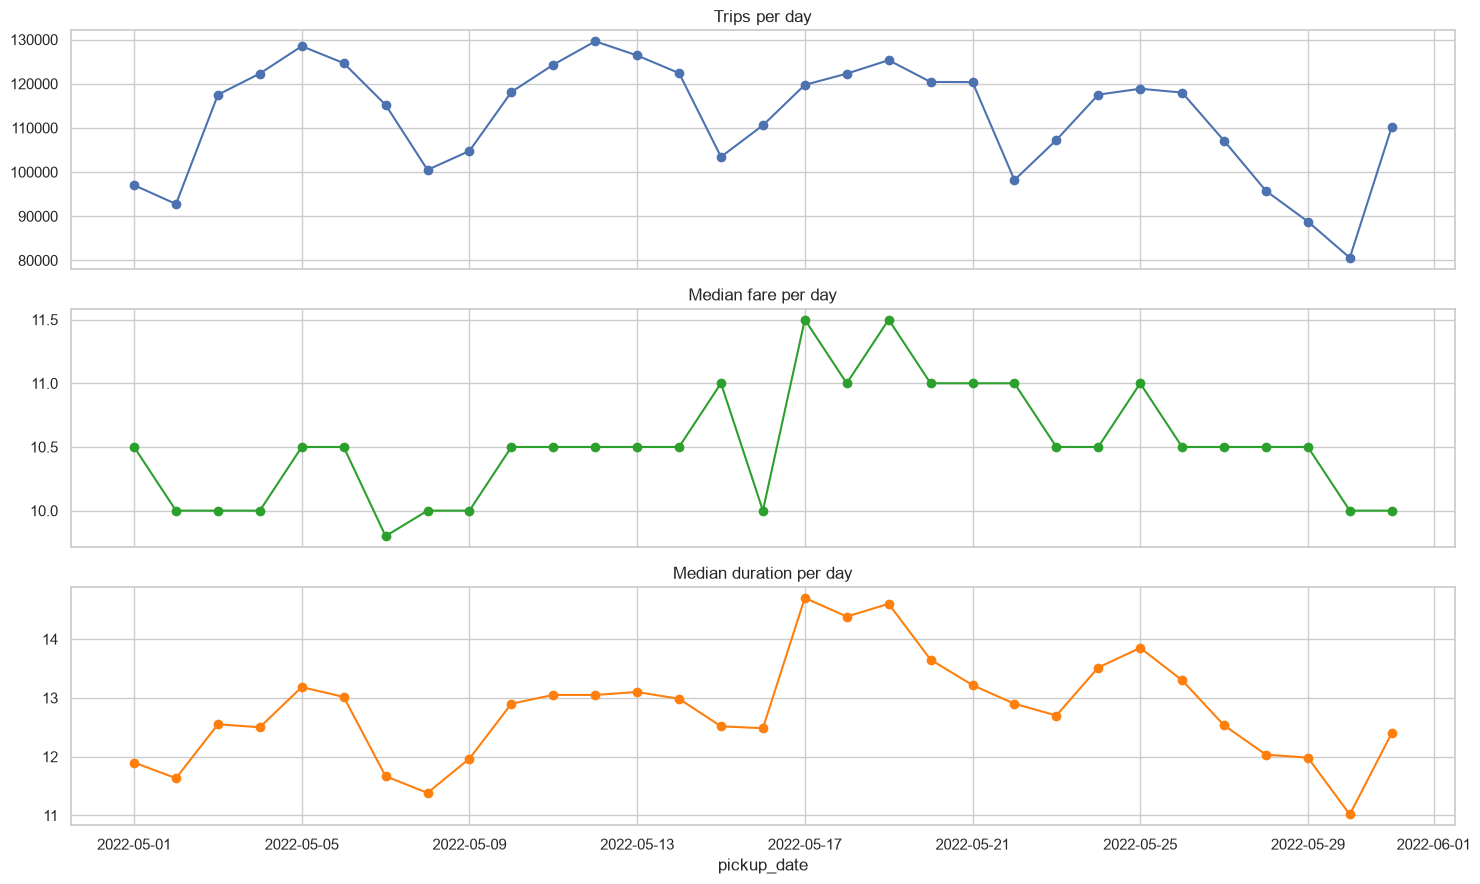

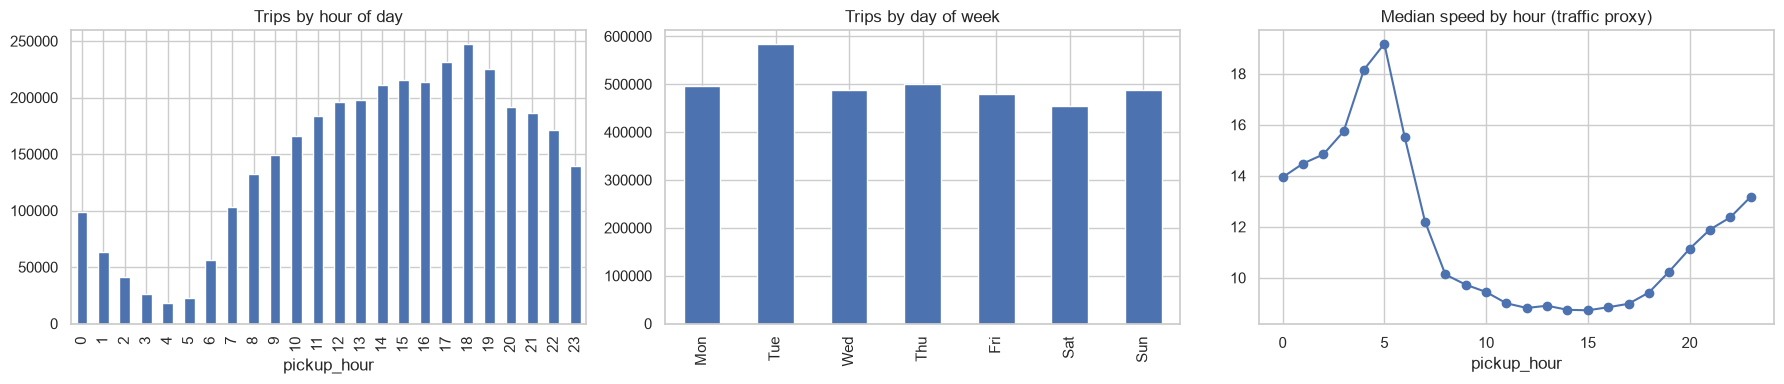

In [23]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Daily series: volume and behavior across the month
daily = clean_fare.groupby("pickup_date").agg(
    trips=("fare_amount", "size"),
    fare=("fare_amount", "median"),
    duration=("duration_min", "median"),
)

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
daily["trips"].plot(ax=axes[0], marker="o", title="Trips per day")
daily["fare"].plot(ax=axes[1], marker="o", color="tab:green", title="Median fare per day")
daily["duration"].plot(ax=axes[2], marker="o", color="tab:orange", title="Median duration per day")
plt.tight_layout()
plt.show()

# Profile by hour of day and day of week
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
by_hour = clean_fare.groupby("pickup_hour").size()
by_hour.plot(kind="bar", ax=axes[0], title="Trips by hour of day")

by_dow = clean_fare.groupby("pickup_dow").size()
by_dow.index = day_names
by_dow.plot(kind="bar", ax=axes[1], title="Trips by day of week")

speed_by_hour = clean_fare.groupby("pickup_hour")["avg_speed_mph"].median()
speed_by_hour.plot(marker="o", ax=axes[2], title="Median speed by hour (traffic proxy)")
plt.tight_layout()
plt.show()

### 4.2 Check correlations

We show two matrices separately, and on purpose. The first covers the legitimate features. The
second covers the leakage columns and exists to document **why** we exclude them despite being the
most predictive of all. That table is the team's defense when someone asks why `total_amount` was
not used.

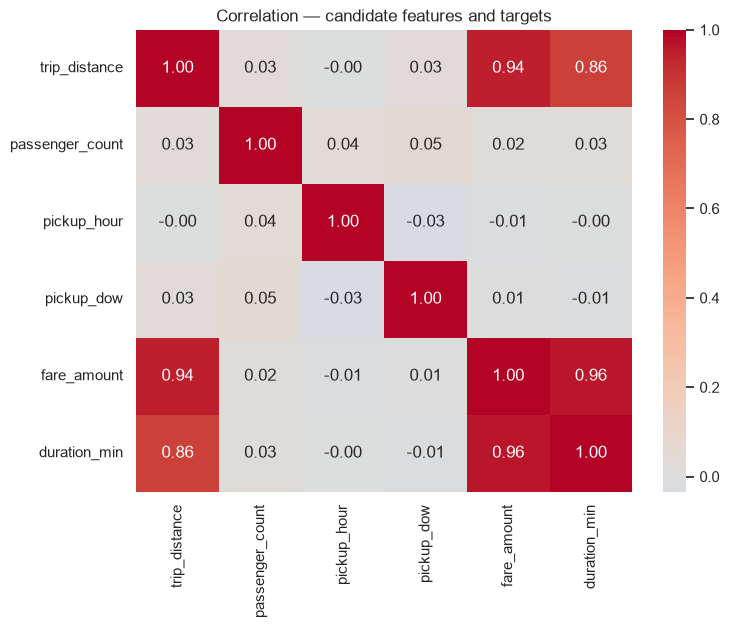

Correlation of the LEAKAGE columns (excluded from the model):


,fare_amount,duration_min
total_amount,0.97,0.93
tip_amount,0.47,0.44
tolls_amount,0.44,0.40
airport_fee,0.42,0.37
improvement_surcharge,-0.01,-0.01
extra,-0.06,-0.05
payment_type,-0.09,-0.06
mta_tax,-0.09,-0.08
congestion_surcharge,-0.19,-0.14


In [24]:
# Matrix 1: candidate features and targets
corr_cols = ["trip_distance", "passenger_count", "pickup_hour", "pickup_dow",
             "fare_amount", "duration_min"]
plt.figure(figsize=(8, 6))
sns.heatmap(sample[corr_cols].astype(float).corr(method="spearman"),
            annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation — candidate features and targets")
plt.show()

# Matrix 2: leakage columns (documented only to justify their exclusion)
leak_num = [c for c in LEAKAGE if c in sample.columns
            and sample[c].dtype.kind in "if"]
leak_corr = (sample[leak_num + TARGETS].astype(float)
             .corr(method="spearman")[TARGETS].drop(TARGETS))
print("Correlation of the LEAKAGE columns (excluded from the model):")
display(leak_corr.sort_values("fare_amount", ascending=False))

### 4.3 Identify outliers

We compare two criteria. The **statistical** one (IQR) flags anything far from the center; the
**physical** one flags the impossible. On this dataset IQR is far too aggressive: it would remove
long airport rides that are perfectly real and that the model needs to see.

In [25]:
def iqr_bounds(series, k=1.5):
    """Return the lower and upper bounds of the classic IQR criterion."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

comparison = []
for col, physical in [("fare_amount", (MIN_FARE, MAX_FARE)),
                      ("duration_min", (MIN_DURATION, MAX_DURATION)),
                      ("trip_distance", (MIN_DISTANCE, MAX_DISTANCE))]:
    lo, hi = iqr_bounds(clean_fare[col])
    comparison.append({
        "column": col,
        "IQR_min": round(lo, 2), "IQR_max": round(hi, 2),
        "IQR_flags_%": round((~clean_fare[col].between(lo, hi)).mean() * 100, 2),
        "physical_min": physical[0], "physical_max": physical[1],
    })
display(pd.DataFrame(comparison))

# The trips IQR would discard: junk, or genuinely expensive rides?
lo_fare, hi_fare = iqr_bounds(clean_fare["fare_amount"])
expensive = clean_fare[clean_fare["fare_amount"] > hi_fare]
print(f"\nTrips IQR would flag as fare outliers: {len(expensive):,}")
print(f"Of those, with an airport pickup or dropoff: {expensive['is_airport_trip'].mean():.1%}")
display(expensive[["trip_distance", "duration_min", "fare_amount", "avg_speed_mph"]]
        .median().to_frame("median"))

,column,IQR_min,IQR_max,IQR_flags_%,physical_min,physical_max
0,fare_amount,-6.68,31.13,9.95,2.50,500
1,duration_min,-11.31,39.82,6.13,1.00,180
2,trip_distance,-2.65,7.62,12.72,0.10,100



Trips IQR would flag as fare outliers: 347,045
Of those, with an airport pickup or dropoff: 80.1%


,median
trip_distance,16.00
duration_min,42.33
fare_amount,52.00
avg_speed_mph,20.40


## 5. Visualize the insights

### 5.1 Histograms — distribution

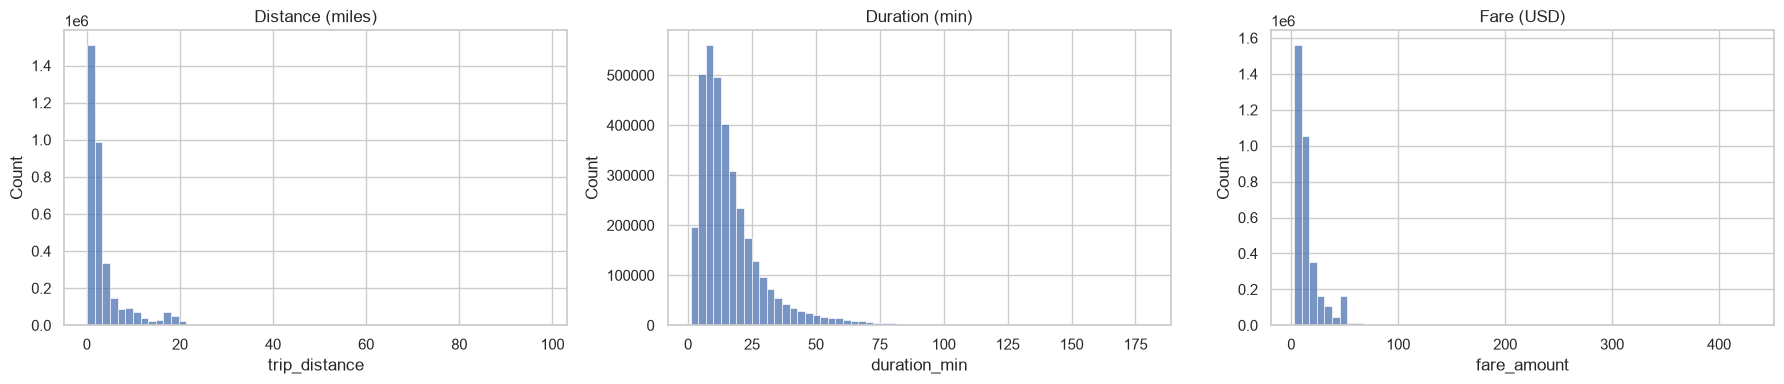

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(clean_fare["trip_distance"], bins=60, ax=axes[0]).set_title("Distance (miles)")
sns.histplot(clean_fare["duration_min"], bins=60, ax=axes[1]).set_title("Duration (min)")
sns.histplot(clean_fare["fare_amount"], bins=60, ax=axes[2]).set_title("Fare (USD)")
plt.tight_layout()
plt.show()

### 5.2 Box plots — spread & outliers

The box plot by segment answers the business question directly: how much does the fare vary within
each time window? The taller the box, the harder it will be for the model to be accurate in that
segment.

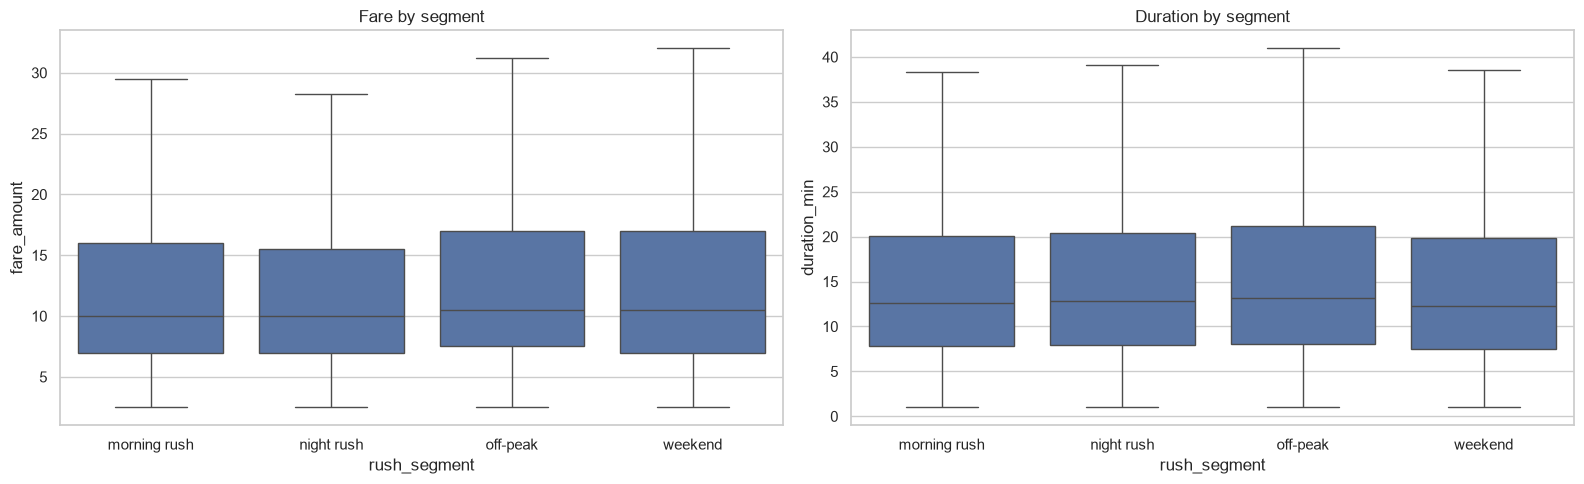

In [27]:
segment_order = ["morning rush", "night rush", "off-peak", "weekend"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=clean_fare, x="rush_segment", y="fare_amount",
            order=segment_order, showfliers=False, ax=axes[0])
axes[0].set_title("Fare by segment")
sns.boxplot(data=clean_fare, x="rush_segment", y="duration_min",
            order=segment_order, showfliers=False, ax=axes[1])
axes[1].set_title("Duration by segment")
plt.tight_layout()
plt.show()

### 5.3 Bar charts — comparison

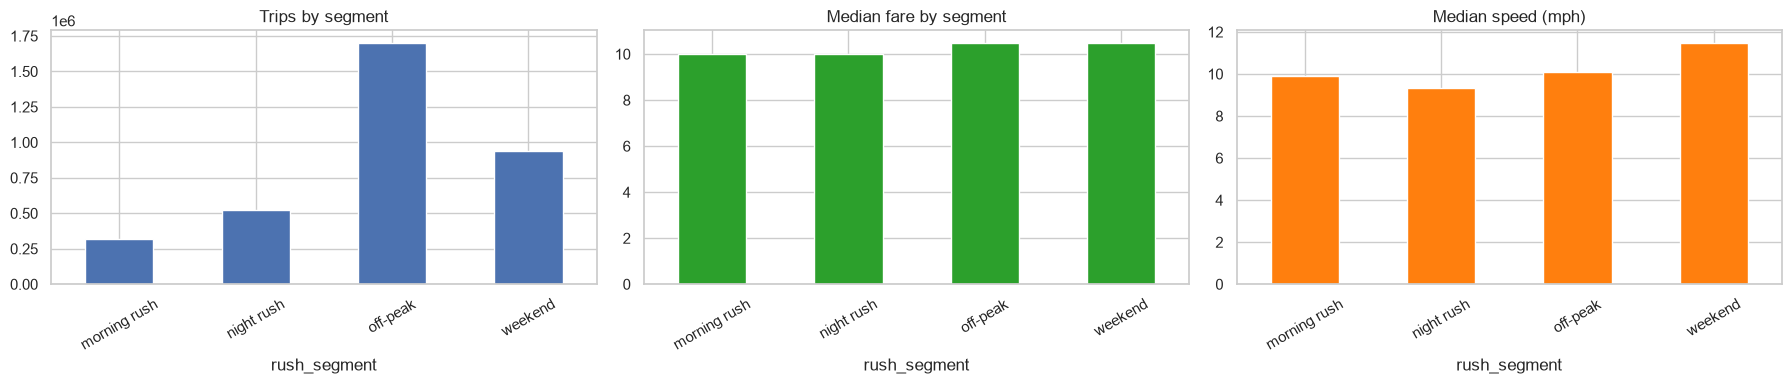

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

by_segment = clean_fare.groupby("rush_segment", observed=True).agg(
    trips=("fare_amount", "size"),
    fare=("fare_amount", "median"),
    speed=("avg_speed_mph", "median"),
).reindex(segment_order)

by_segment["trips"].plot(kind="bar", ax=axes[0], title="Trips by segment")
by_segment["fare"].plot(kind="bar", ax=axes[1], color="tab:green", title="Median fare by segment")
by_segment["speed"].plot(kind="bar", ax=axes[2], color="tab:orange", title="Median speed (mph)")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 5.4 Scatter plots — relationships

Color separates the time segments. We expect the fare to rise almost linearly with distance (that is
the meter), while duration scatters much more, because it depends on traffic. That difference is an
early sign that duration will be the harder target to predict.

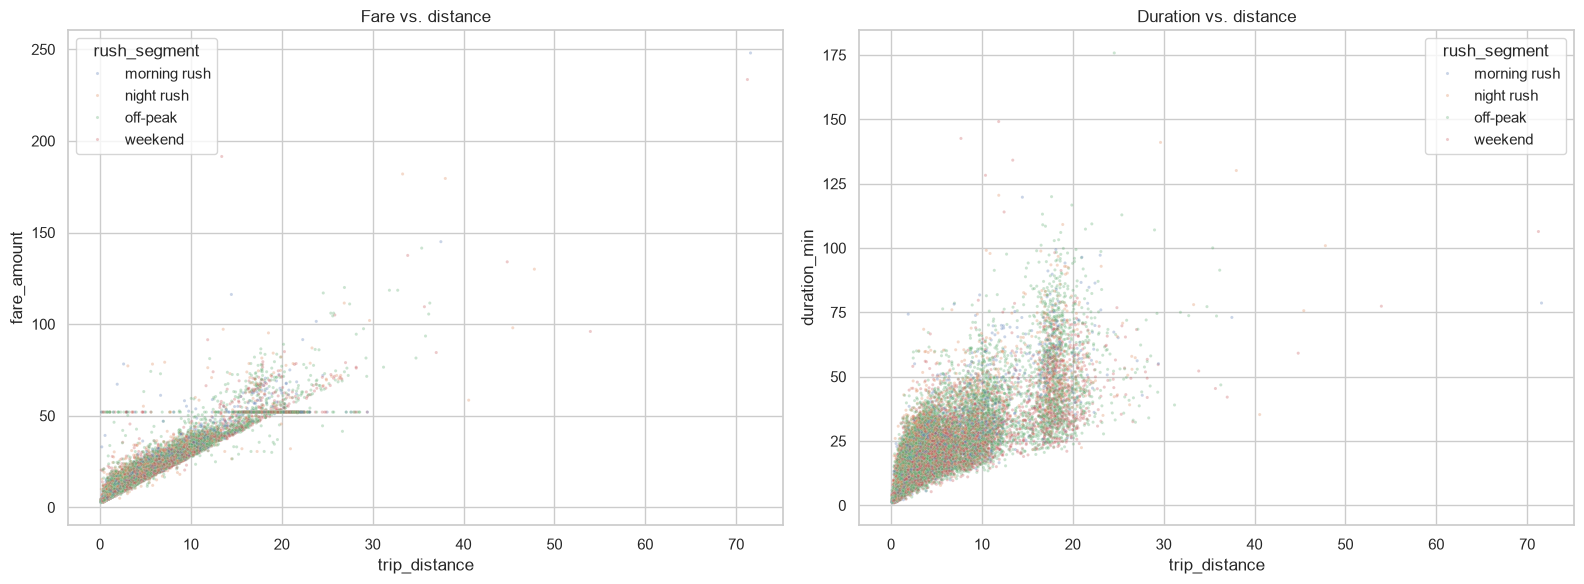

In [29]:
scatter_sample = sample.sample(n=min(40_000, len(sample)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=scatter_sample, x="trip_distance", y="fare_amount", hue="rush_segment",
                hue_order=segment_order, s=5, alpha=0.3, ax=axes[0])
axes[0].set_title("Fare vs. distance")
sns.scatterplot(data=scatter_sample, x="trip_distance", y="duration_min", hue="rush_segment",
                hue_order=segment_order, s=5, alpha=0.3, ax=axes[1])
axes[1].set_title("Duration vs. distance")
plt.tight_layout()
plt.show()

### 5.5 Heat maps

The first two maps cross hour of day against day of week. The third and fourth answer the questions
from the outline directly: how fare and duration behave in each congestion segment, controlling for
trip distance. Controlling for distance is essential: without it you cannot tell whether a segment
is more expensive because of traffic or simply because people take longer rides then.

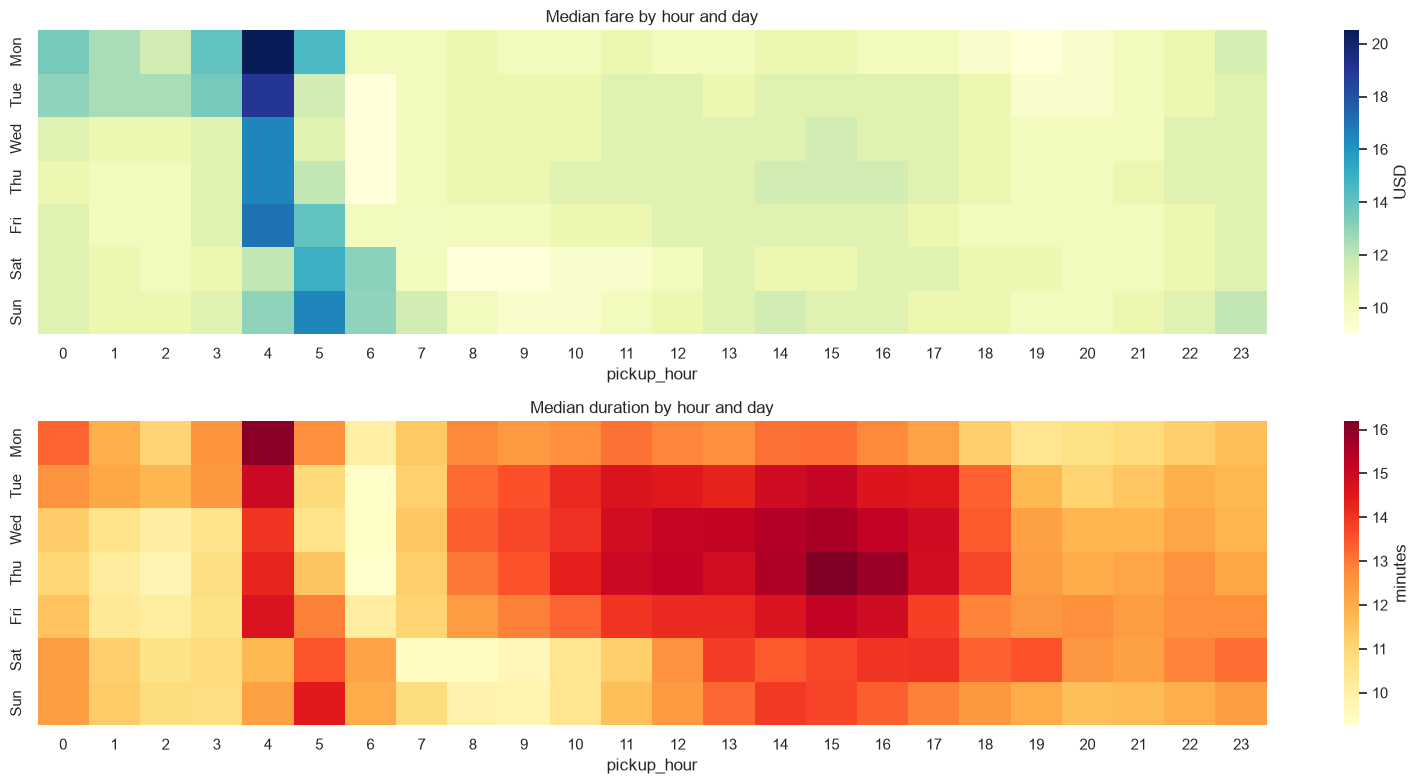

In [30]:
# Maps 1 and 2: hour of day x day of week
pivot_fare = clean_fare.pivot_table(index="pickup_dow", columns="pickup_hour",
                                    values="fare_amount", aggfunc="median")
pivot_duration = clean_fare.pivot_table(index="pickup_dow", columns="pickup_hour",
                                        values="duration_min", aggfunc="median")
pivot_fare.index = day_names
pivot_duration.index = day_names

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
sns.heatmap(pivot_fare, cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "USD"})
axes[0].set_title("Median fare by hour and day")
sns.heatmap(pivot_duration, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "minutes"})
axes[1].set_title("Median duration by hour and day")
plt.tight_layout()
plt.show()

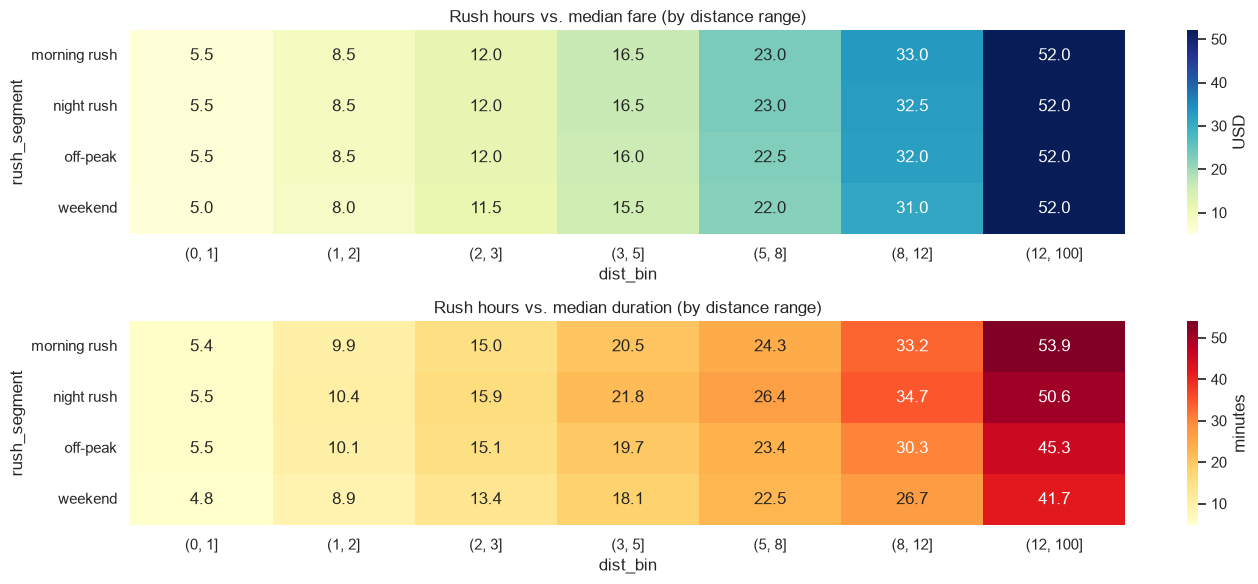

In [31]:
# Maps 3 and 4: congestion segment x distance range
# The binning happens on a temporary copy: interval columns cannot be written to
# Parquet, so they must not survive into the final dataset
binned = clean_fare.assign(
    dist_bin=pd.cut(clean_fare["trip_distance"], bins=[0, 1, 2, 3, 5, 8, 12, 100])
)

pivot_rush_fare = binned.pivot_table(index="rush_segment", columns="dist_bin",
                                     values="fare_amount", aggfunc="median",
                                     observed=True).reindex(segment_order)
pivot_rush_duration = binned.pivot_table(index="rush_segment", columns="dist_bin",
                                         values="duration_min", aggfunc="median",
                                         observed=True).reindex(segment_order)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
sns.heatmap(pivot_rush_fare, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={"label": "USD"})
axes[0].set_title("Rush hours vs. median fare (by distance range)")
sns.heatmap(pivot_rush_duration, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={"label": "minutes"})
axes[1].set_title("Rush hours vs. median duration (by distance range)")
plt.tight_layout()
plt.show()

## 6. Generate business insights

### 6.1 Identify key takeaways

This cell computes the concrete numbers that go into the presentation. The point is not to write
conclusions by hand: they come from the data and update themselves if the cleaning rules change.

In [32]:
print("=" * 60)
print("KEY FINDINGS — NY TaxiAID / May 2022")
print("=" * 60)

print(f"\nVolume: {len(df):,} trips in the original file")
print(f"Usable dataset for fare: {len(clean_fare):,} ({len(clean_fare)/len(df):.1%})")
print(f"Usable dataset for duration: {len(clean_duration):,} ({len(clean_duration)/len(df):.1%})")

print(f"\nTypical trip: {clean_fare['trip_distance'].median():.1f} miles, "
      f"{clean_fare['duration_min'].median():.0f} min, "
      f"USD {clean_fare['fare_amount'].median():.2f}")

# Impact of congestion, controlling for distance (2 to 5 mile trips)
mid_range = clean_fare[clean_fare["trip_distance"].between(2, 5)]
segment_comparison = mid_range.groupby("rush_segment", observed=True).agg(
    duration=("duration_min", "median"),
    fare=("fare_amount", "median"),
    speed=("avg_speed_mph", "median"),
).reindex(segment_order)
print("\nTrips between 2 and 5 miles, by segment:")
display(segment_comparison)

if {"morning rush", "off-peak"}.issubset(segment_comparison.index):
    extra_time = (segment_comparison.loc["morning rush", "duration"]
                  - segment_comparison.loc["off-peak", "duration"])
    extra_fare = (segment_comparison.loc["morning rush", "fare"]
                  - segment_comparison.loc["off-peak", "fare"])
    print(f"Morning rush vs. off-peak: {extra_time:+.1f} min and USD {extra_fare:+.2f} "
          f"for the same distance")

# Weight of airport trips
airport_fare = clean_fare[clean_fare["is_airport_trip"]]["fare_amount"].median()
print(f"\nTrips with an airport pickup or dropoff: {clean_fare['is_airport_trip'].mean():.1%} "
      f"of the total, median fare USD {airport_fare:.2f}")

# Relative difficulty of each target
cv_fare = clean_fare["fare_amount"].std() / clean_fare["fare_amount"].mean()
cv_duration = clean_fare["duration_min"].std() / clean_fare["duration_min"].mean()
print(f"\nRelative variability (CV): fare {cv_fare:.2f} | duration {cv_duration:.2f}")
print("A higher CV points to the harder target to predict.")

KEY FINDINGS — NY TaxiAID / May 2022

Volume: 3,588,295 trips in the original file
Usable dataset for fare: 3,488,484 (97.2%)
Usable dataset for duration: 3,498,198 (97.5%)

Typical trip: 2.0 miles, 13 min, USD 10.50

Trips between 2 and 5 miles, by segment:


,duration,fare,speed
rush_segment,,,
morning rush,16.77,13.50,10.13
night rush,17.80,13.50,9.56
off-peak,16.85,13.50,10.40
weekend,15.30,13.00,11.60


Morning rush vs. off-peak: -0.1 min and USD +0.00 for the same distance

Trips with an airport pickup or dropoff: 10.6% of the total, median fare USD 44.00

Relative variability (CV): fare 0.85 | duration 0.81
A higher CV points to the harder target to predict.


### 6.2 Suggest recommendations

**For modeling** (fill in with the numbers printed above):

- Train **two separate models** on two different datasets: negotiated fares are excluded from the
  fare model but kept for the duration model.
- Test a log-transformed target, given the right skew of both distributions.
- Include the congestion flags (`morning_rush`, `night_rush`, `weekend_rush`) as features: the heat
  maps show that the same distance takes different amounts of time depending on when it happens.
- Use `is_airport_trip` as a feature: JFK trips have a flat fare and follow a fixed rule the model
  can learn easily.
- Respect the **temporal order** in the split: train on the first days of May and evaluate on the
  last ones. A random split would use the future to predict the past.

**For the business:**

- Fare is far more predictable than duration, because the meter computes it almost linearly from
  distance. Communicate the fare as a single number and the duration as a range.
- The rush-hour premium is the commercial argument against ridesharing: a taxi can show the price up
  front while competitors apply variable surge pricing.
- Errors are not symmetric. Promising 20 and charging 30 destroys trust; promising 30 and charging 20
  reinforces it. A slightly conservative model (quantile regression) is worth evaluating.

### 6.3 Support business decisions

Proposed acceptance criterion to discuss with stakeholders, more useful than a bare MAE:

> 90% of estimates must fall within ±15% of the actual fare.

**Known limitations that belong in the presentation:**

- The model does not predict negotiated fares (`RatecodeID` 5), because a person sets them.
- It is trained on a single month, so it captures no annual seasonality and no atypical events.
- Production will use a distance **estimated** by a routing service, while training uses the
  **actual** distance measured by the meter.

### 6.4 Save the clean dataset

We export to Parquet for the rest of the team. These files are what later gets loaded into the
database and what feeds the training notebooks.

In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

clean_fare.to_parquet("../data/processed/clean_fare.parquet", index=False)
clean_duration.to_parquet("../data/processed/clean_duration.parquet", index=False)

print("Datasets saved to data/processed/")
print(f"  clean_fare.parquet     {len(clean_fare):,} rows")
print(f"  clean_duration.parquet {len(clean_duration):,} rows")

Datasets saved to data/processed/
  clean_fare.parquet     3,488,484 rows
  clean_duration.parquet 3,498,198 rows
